# GLM-5.3-Flash TP4 on 4× CMP 170HX — 74 SMs, equalised HBM clock, power-cap sweep

| Metric | Value |
|---|---:|
| Decode, 1 user, structured / code / prose (150 W, HBM 1,728 MHz on all cards) | **418.0 / 309.9 / 214.1 tok/s** |
| Decode, 8 users aggregate, structured (150 W) | **816.5 tok/s** |
| Same at the new 140 W default | 412.7 / 305.9 / 211.6 · 814.2 tok/s |
| Best tokens per watt (8 users, GPU boards only) | 1.62 tok/s/W at 110 W (vs 1.40 at 150 W) |
| Prefill / TTFT | untested in this run (see the 2026-10-01 notebook) |

![decode vs power cap](../assets/charts/2026-10-02-glm-5.3-flash-4card-tp4-sm74-hbm-power-vllm.png)

```bash
git clone https://github.com/Morrowmake/glm53-flash-cmp170hx-recipe && cd glm53-flash-cmp170hx-recipe && git checkout v1.6.0
```

Evidence: [`results/2026-10-02-glm-5.3-flash-4card-tp4-plx-sm74-hbm-power/`](../results/2026-10-02-glm-5.3-flash-4card-tp4-plx-sm74-hbm-power/README.md) · card background: [CMP 170HX understanding](../docs/CMP170HX-UNDERSTANDING.md)

In [1]:
# --- Status cell ---
import os
EXPERIMENT = "2026-10-02-glm-5.3-flash-4card-tp4-plx-sm74-hbm-power"
RESULTS_DIR = "../results/" + EXPERIMENT
RECEIPTS = RESULTS_DIR + "/receipts"
PRIOR = "../results/2026-10-01-glm-5.3-flash-morrowmake-1.6.0-4card-tp4-plx/receipts"   # 70-SM, 180 W run from 2026-10-01
LIVE = False  # True sends the final request to the endpoint in GLM_URL (an OpenAI-compatible /v1 base)
ENDPOINT_ENV_VAR = "GLM_URL"
print("LIVE =", LIVE, "| receipts:", RECEIPTS)

LIVE = False | receipts: ../results/2026-10-02-glm-5.3-flash-4card-tp4-plx-sm74-hbm-power/receipts


In [2]:
# --- Helpers: receipts, tables, chart style ---
import json, csv, statistics
from IPython.display import display, Markdown
import matplotlib
import matplotlib.pyplot as plt

def receipt(base, *parts):
    with open("/".join([base, *parts])) as f:
        return json.load(f)

def table(header, rows):
    out = ["| " + " | ".join(header) + " |", "|" + "|".join("---:" if i else "---" for i in range(len(header))) + "|"]
    out += ["| " + " | ".join(str(c) for c in r) + " |" for r in rows]
    display(Markdown("\n".join(out)))

S = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
INK, INK2, GRID, SURF = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
matplotlib.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "axes.edgecolor": GRID, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False, "font.size": 9,
    "axes.titlesize": 10, "axes.titlecolor": INK, "legend.frameon": False, "lines.linewidth": 2,
})

def label_bars(ax, bars, fmt="{:.0f}"):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), fmt.format(b.get_height()), va="bottom", ha="center", color=INK2, fontsize=7)

PROMPTS = ("structured", "coding", "prose")

def matrix(base, run):
    d = {}
    for c in (1, 8):
        for p in PROMPTS:
            r = receipt(base, run, f"decode-{p}-c{c}.json")
            d[(p, c)] = {"tok": r["tok_s_median"] if c == 1 else r["aggregate_tok_s_median"],
                         "step": r["decode_ms_per_draft_step_median"], "acc": r["accepted_per_step_median"]}
    return d

def num(x):
    return float("".join(ch for ch in x if ch.isdigit() or ch == ".") or 0)

def telemetry(run):
    rows = [r for r in csv.reader(open(f"{RECEIPTS}/{run}/telemetry.csv"), skipinitialspace=True) if len(r) >= 8 and r[1].strip().isdigit()]
    busy = [r for r in rows if num(r[7]) > 50]
    out = {"busy_w": 0.0, "core": {}, "hbm": {}, "sm_p50": 0}
    for i in range(4):
        p = [num(r[4]) for r in busy if int(r[1]) == i]
        out["busy_w"] += sum(p) / len(p) if p else 0
        out["core"][i] = max(num(r[2]) for r in rows if int(r[1]) == i)
        out["hbm"][i] = max(num(r[3]) for r in rows if int(r[1]) == i)
    clk = sorted(num(r[5]) for r in busy)
    out["sm_p50"] = clk[len(clk) // 2] if clk else 0
    return out

## 1. TL;DR

- **Measured:** two of the four cards ship a VBIOS (`92.00.67.00.01`) that runs HBM at NDIV 54 = 1,458 MHz; the other two (`92.00.6D.00.0A`) run NDIV 64 = 1,728 MHz, same board part number, same timings. TP4 waits for the slowest card. After a hot 170tune gate (12/12 sweeps, peak HBM 75 °C) the two slow cards run NDIV 64: decode step 19.5 → 18.4 ms, single-user +5.8 to +6.3%, eight-user +3.1 to +3.8%, same draft acceptance.
- **Measured:** 70 → 74 SMs (cmpunlocker `6c442ee`) shows no clear decode gain; the comparison crosses a power-cap change (180 W → 150 W), so it is not a clean A/B.
- **Measured:** power-cap sweep on the live server. 140 W keeps 98.7–99.7% of 150 W throughput for 8% less GPU power; 110 W gives the most tokens per watt (1.62 vs 1.40) at 13–22% lower throughput; 100 W loses on both; 165 W adds 0.1–1.1% and runs HBM at 82–83 °C. The host's default is now 140 W.
- **Measured:** sm80vllm copy drafts: +37% on an edit reply that repeats the prompt (byte-identical), +28% on a second edit task (reply differs), −0.3 to −2.2% on general decode.
- **Pending:** SM VF offset +200 (gates passing on 2 of 4 cards at the time of writing; serving bench not run).

In [3]:
pins = {
    "recipe": "Morrowmake/glm53-flash-cmp170hx-recipe @ a242b4f (v1.6.0); --gpus all -> --device nvidia.com/gpu=all (LXC/CDI)",
    "engine image": "ghcr.io/morrowmake/vllm-cmp170hx@sha256:cc26c8abb639… (vLLM fork v0.30.1rc1.dev301+g3a2bf16da)",
    "copy-drafts image": "pixelml/sm80vllm:tf-learnings-c93c274c8 (built locally from PixelML/sm80vllm, not published)",
    "target / drafter": "canada-quant/GLM-5.3-Flash-W4A16-MTP @ 5723f4d02a · incoai/GLM-5.3-Flash-DFlash2 @ bf582e4eac (CC BY-NC-ND 4.0, benchmark only)",
    "driver": "615.71.09 open; cmpunlocker 88e39ce + 6c442ee (+4 SM) + PR #60 HBM PLMs + rebar-serialize + 4 BAR1-P2P patches",
    "HBM clock": "170tune 5eb4775: NDIV 64 on the two NDIV-54 cards (hot gate, persisted)",
    "host": "Proxmox VE 9.2.2, kernel 7.0.2-6-pve; server in a privileged LXC sharing the host driver",
    "topology": "TP4, P2P off + replicated embedding, 4 × Gen2 x16, 2 cards per PLX PEX 8747, one CPU socket",
}
table(["pin", "value"], pins.items())

| pin | value |
|---|---:|
| recipe | Morrowmake/glm53-flash-cmp170hx-recipe @ a242b4f (v1.6.0); --gpus all -> --device nvidia.com/gpu=all (LXC/CDI) |
| engine image | ghcr.io/morrowmake/vllm-cmp170hx@sha256:cc26c8abb639… (vLLM fork v0.30.1rc1.dev301+g3a2bf16da) |
| copy-drafts image | pixelml/sm80vllm:tf-learnings-c93c274c8 (built locally from PixelML/sm80vllm, not published) |
| target / drafter | canada-quant/GLM-5.3-Flash-W4A16-MTP @ 5723f4d02a · incoai/GLM-5.3-Flash-DFlash2 @ bf582e4eac (CC BY-NC-ND 4.0, benchmark only) |
| driver | 615.71.09 open; cmpunlocker 88e39ce + 6c442ee (+4 SM) + PR #60 HBM PLMs + rebar-serialize + 4 BAR1-P2P patches |
| HBM clock | 170tune 5eb4775: NDIV 64 on the two NDIV-54 cards (hot gate, persisted) |
| host | Proxmox VE 9.2.2, kernel 7.0.2-6-pve; server in a privileged LXC sharing the host driver |
| topology | TP4, P2P off + replicated embedding, 4 × Gen2 x16, 2 cards per PLX PEX 8747, one CPU socket |

## 2. Results (measured)

Decode matrix: MiaAI-Lab `bench_decode.py` @ 943912cd, T=0, thinking off, 400 tokens, median of 5, at 1 and 8 users. Busy power = mean board power while utilisation > 50%, summed over four cards. Tokens per watt = eight-user structured aggregate ÷ busy power.

In [4]:
RUNS = [
    ("sm74-150w", "74 SM, mixed HBM", 150),
    ("sm74-hbm64-165w", "74 SM, HBM equal", 165),
    ("sm74-hbm64-150w", "74 SM, HBM equal", 150),
    ("sm74-hbm64-140w", "74 SM, HBM equal", 140),
    ("sm74-hbm64-130w", "74 SM, HBM equal", 130),
    ("sm74-hbm64-120w", "74 SM, HBM equal", 120),
    ("sm74-hbm64-110w", "74 SM, HBM equal", 110),
    ("sm74-hbm64-100w", "74 SM, HBM equal", 100),
]
M = {k: matrix(RECEIPTS, k) for k, _, _ in RUNS}
T = {k: telemetry(k) for k, _, _ in RUNS}
M["prior"] = matrix(PRIOR, "tp4-p2p-off-repembed")
rows = []
for k, lab, w in RUNS:
    m, t = M[k], T[k]
    rows.append([lab, f"{w} W", " / ".join(f"{m[(p, 1)]['tok']:.1f}" for p in PROMPTS), " / ".join(f"{m[(p, 8)]['tok']:.1f}" for p in PROMPTS),
                 f"{m[('structured', 1)]['step']:.2f}", f"{t['busy_w']:.0f}", f"{m[('structured', 8)]['tok'] / t['busy_w']:.2f}", f"{t['sm_p50']:.0f}"])
m = M["prior"]
rows.append(["*70 SM, mixed HBM (2026-10-01)*", "180 W", " / ".join(f"{m[(p, 1)]['tok']:.1f}" for p in PROMPTS), " / ".join(f"{m[(p, 8)]['tok']:.1f}" for p in PROMPTS), f"{m[('structured', 1)]['step']:.2f}", "—", "—", "—"])
table(["run", "cap", "1 user tok/s (struct / code / prose)", "8 users tok/s", "ms/step (1u struct)", "busy GPU W", "8u tok/s per W", "busy SM clock p50 (MHz)"], rows)
print("accepted per step, 1 user structured:", sorted({M[k][("structured", 1)]["acc"] for k, _, _ in RUNS} | {M["prior"][("structured", 1)]["acc"]}))

| run | cap | 1 user tok/s (struct / code / prose) | 8 users tok/s | ms/step (1u struct) | busy GPU W | 8u tok/s per W | busy SM clock p50 (MHz) |
|---|---:|---:|---:|---:|---:|---:|---:|
| 74 SM, mixed HBM | 150 W | 393.2 / 291.9 / 202.3 | 791.9 / 702.2 / 533.6 | 19.51 | 582 | 1.36 | 1350 |
| 74 SM, HBM equal | 165 W | 418.6 / 311.0 / 214.7 | 822.4 / 735.7 / 558.9 | 18.33 | 650 | 1.27 | 1335 |
| 74 SM, HBM equal | 150 W | 418.0 / 309.9 / 214.1 | 816.5 / 729.0 / 552.7 | 18.36 | 582 | 1.40 | 1320 |
| 74 SM, HBM equal | 140 W | 412.7 / 305.9 / 211.6 | 814.2 / 725.0 / 549.0 | 18.59 | 537 | 1.52 | 1290 |
| 74 SM, HBM equal | 130 W | 394.9 / 290.8 / 201.9 | 785.9 / 696.6 / 527.9 | 19.43 | 517 | 1.52 | 1200 |
| 74 SM, HBM equal | 120 W | 374.4 / 274.0 / 191.5 | 756.5 / 665.6 / 495.6 | 20.50 | 476 | 1.59 | 1110 |
| 74 SM, HBM equal | 110 W | 340.1 / 241.1 / 172.0 | 706.8 / 602.1 / 447.2 | 22.56 | 436 | 1.62 | 1065 |
| 74 SM, HBM equal | 100 W | 291.9 / 205.1 / 146.9 | 627.4 / 528.1 / 391.2 | 26.29 | 398 | 1.58 | 1050 |
| *70 SM, mixed HBM (2026-10-01)* | 180 W | 398.4 / 307.3 / 192.9 | 812.0 / 721.9 / 518.6 | 19.26 | — | — | — |

accepted per step, 1 user structured: [6.692]


### 2.1 Headline: decode and efficiency vs power cap

Left: single-user and eight-user structured decode per cap (HBM equalised). Right: eight-user tokens per watt. Exported to `assets/charts/` as the notebook's headline chart.

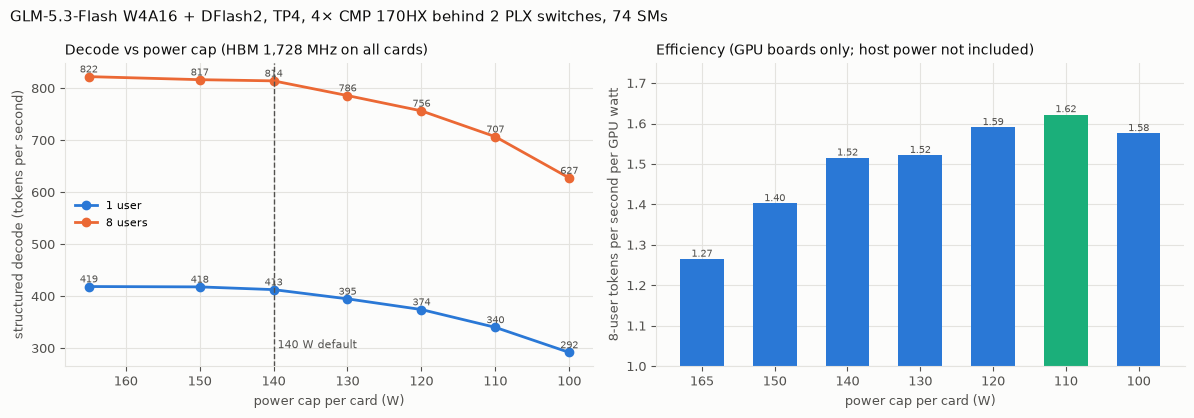

In [5]:
sweep = [r for r in RUNS if r[0].startswith("sm74-hbm64")]
caps = [w for _, _, w in sweep]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for c, col in ((1, S[0]), (8, S[1])):
    ys = [M[k][("structured", c)]["tok"] for k, _, _ in sweep]
    axes[0].plot(caps, ys, marker="o", color=col, label=f"{c} user{'s' if c > 1 else ''}")
    for x, y in zip(caps, ys):
        axes[0].text(x, y + 8, f"{y:.0f}", ha="center", color=INK2, fontsize=7)
axes[0].axvline(140, color=INK2, ls="--", lw=1); axes[0].text(140, 300, " 140 W default", color=INK2, fontsize=8)
axes[0].set_xlabel("power cap per card (W)"); axes[0].set_ylabel("structured decode (tokens per second)")
axes[0].set_title("Decode vs power cap (HBM 1,728 MHz on all cards)", loc="left"); axes[0].legend(fontsize=8, loc="center left"); axes[0].invert_xaxis()
eff = [M[k][("structured", 8)]["tok"] / T[k]["busy_w"] for k, _, _ in sweep]
bars = axes[1].bar([str(w) for w in caps], eff, color=[S[2] if e == max(eff) else S[0] for e in eff], width=0.6)
label_bars(axes[1], bars, "{:.2f}")
axes[1].set_xlabel("power cap per card (W)"); axes[1].set_ylabel("8-user tokens per second per GPU watt")
axes[1].set_title("Efficiency (GPU boards only; host power not included)", loc="left"); axes[1].set_ylim(1.0, 1.75)
fig.suptitle("GLM-5.3-Flash W4A16 + DFlash2, TP4, 4× CMP 170HX behind 2 PLX switches, 74 SMs", color=INK, x=0.01, ha="left")
fig.tight_layout()
os.makedirs("../assets/charts", exist_ok=True)
fig.savefig("../assets/charts/2026-10-02-glm-5.3-flash-4card-tp4-sm74-hbm-power-vllm.png", dpi=150, bbox_inches="tight"); fig.savefig("../assets/charts/2026-10-02-glm-5.3-flash-4card-tp4-sm74-hbm-power-vllm.svg", bbox_inches="tight")
plt.show()

### 2.2 What the HBM clock and the extra SMs did (150 W, one change at a time)

Three runs: 70 SM / mixed HBM at 180 W (2026-10-01), 74 SM / mixed HBM at 150 W, 74 SM / equal HBM at 150 W. The first step also changes the power cap, so read it as context, not as an A/B.

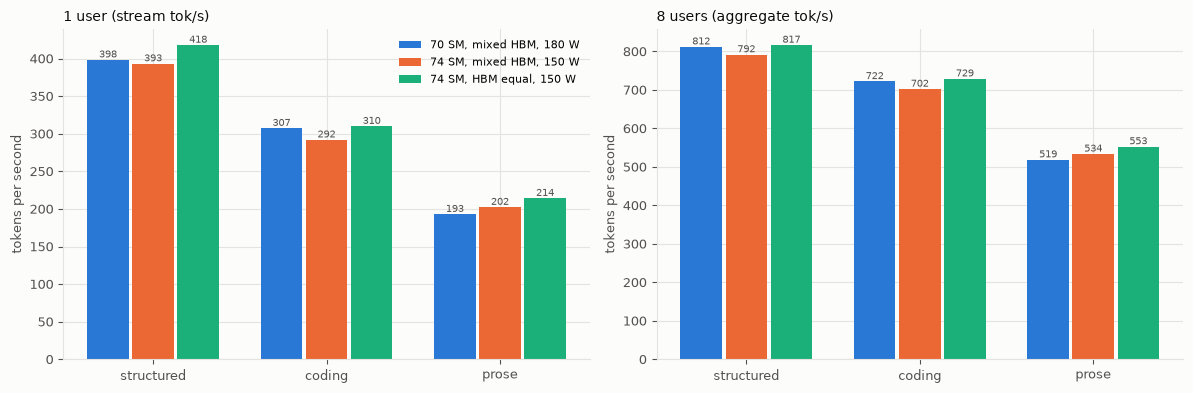

| prompt | users | mixed HBM | HBM equal | change | ms/step mixed → equal |
|---|---:|---:|---:|---:|---:|
| structured | 1 | 393.2 | 418.0 | +6.3% | 19.51 → 18.36 |
| coding | 1 | 291.9 | 309.9 | +6.2% | 20.40 → 19.21 |
| prose | 1 | 202.3 | 214.1 | +5.9% | 19.15 → 18.09 |
| structured | 8 | 791.9 | 816.5 | +3.1% | 4.41 → 4.26 |
| coding | 8 | 702.2 | 729.0 | +3.8% | 4.72 → 4.52 |
| prose | 8 | 533.6 | 552.7 | +3.6% | 4.78 → 4.61 |

In [6]:
steps = [("prior", "70 SM, mixed HBM, 180 W"), ("sm74-150w", "74 SM, mixed HBM, 150 W"), ("sm74-hbm64-150w", "74 SM, HBM equal, 150 W")]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.0))
for ax, c, title in ((axes[0], 1, "1 user (stream tok/s)"), (axes[1], 8, "8 users (aggregate tok/s)")):
    w = 0.26
    for i, (k, lab) in enumerate(steps):
        bars = ax.bar([j + (i - 1) * w for j in range(3)], [M[k][(p, c)]["tok"] for p in PROMPTS], w * 0.92, color=S[i], label=lab)
        label_bars(ax, bars)
    ax.set_xticks(range(3), PROMPTS); ax.set_title(title, loc="left"); ax.set_ylabel("tokens per second")
axes[0].legend(fontsize=8, loc="upper right")
fig.tight_layout(); plt.show()
base, new = M["sm74-150w"], M["sm74-hbm64-150w"]
table(["prompt", "users", "mixed HBM", "HBM equal", "change", "ms/step mixed → equal"],
      [[p, c, f"{base[(p, c)]['tok']:.1f}", f"{new[(p, c)]['tok']:.1f}", f"{(new[(p, c)]['tok'] / base[(p, c)]['tok'] - 1) * 100:+.1f}%",
        f"{base[(p, c)]['step']:.2f} → {new[(p, c)]['step']:.2f}"] for c in (1, 8) for p in PROMPTS])

### 2.3 Step time vs core clock across the sweep

Below 140 W the busy core clock drops and the decode step lengthens with it; between 140 and 165 W the core clock barely moves and neither does decode.

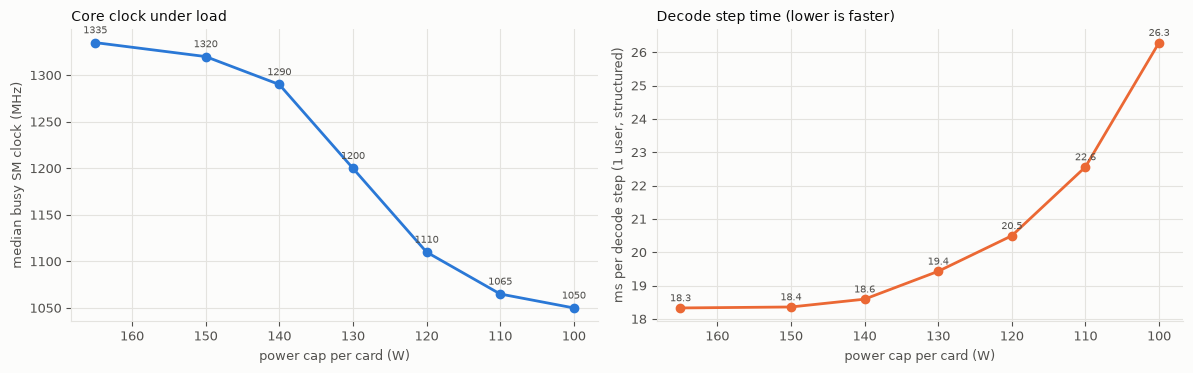

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
clk = [T[k]["sm_p50"] for k, _, _ in sweep]
axes[0].plot(caps, clk, marker="o", color=S[0])
for x, y in zip(caps, clk):
    axes[0].text(x, y + 10, f"{y:.0f}", ha="center", color=INK2, fontsize=7)
axes[0].set_xlabel("power cap per card (W)"); axes[0].set_ylabel("median busy SM clock (MHz)"); axes[0].invert_xaxis()
axes[0].set_title("Core clock under load", loc="left")
st = [M[k][("structured", 1)]["step"] for k, _, _ in sweep]
axes[1].plot(caps, st, marker="o", color=S[1])
for x, y in zip(caps, st):
    axes[1].text(x, y + 0.2, f"{y:.1f}", ha="center", color=INK2, fontsize=7)
axes[1].set_xlabel("power cap per card (W)"); axes[1].set_ylabel("ms per decode step (1 user, structured)"); axes[1].invert_xaxis()
axes[1].set_title("Decode step time (lower is faster)", loc="left")
fig.tight_layout(); plt.show()

### 2.4 Temperatures per run

Peak core and HBM temperature per card (1 s samples). Runs were back to back on a warm server, highest cap first, so heat carries over from one run to the next; read the trend, not single values. The 140 W run was the first of the sweep and started from an idle, cool server, which is why it reads cooler than the 130 W run after it. The 165 W run crossed this repository's 80 °C core stop rule on one card (flagged, kept).

In [8]:
rows = []
for k, lab, w in RUNS:
    t = T[k]
    flag = "above 80 °C core rule" if max(t["core"].values()) >= 80 else ""
    rows.append([f"{lab}, {w} W", ", ".join(f"{t['core'][i]:.0f}" for i in range(4)), ", ".join(f"{t['hbm'][i]:.0f}" for i in range(4)), flag])
table(["run", "peak core °C (gpu0..3)", "peak HBM °C (gpu0..3)", "note"], rows)

| run | peak core °C (gpu0..3) | peak HBM °C (gpu0..3) | note |
|---|---:|---:|---:|
| 74 SM, mixed HBM, 150 W | 69, 71, 62, 64 | 74, 73, 72, 73 |  |
| 74 SM, HBM equal, 165 W | 79, 82, 71, 74 | 82, 83, 79, 79 | above 80 °C core rule |
| 74 SM, HBM equal, 150 W | 69, 71, 63, 65 | 75, 74, 73, 73 |  |
| 74 SM, HBM equal, 140 W | 61, 63, 57, 58 | 70, 67, 68, 68 |  |
| 74 SM, HBM equal, 130 W | 66, 69, 60, 62 | 73, 73, 71, 72 |  |
| 74 SM, HBM equal, 120 W | 67, 72, 61, 63 | 74, 75, 71, 72 |  |
| 74 SM, HBM equal, 110 W | 66, 71, 59, 62 | 74, 74, 70, 71 |  |
| 74 SM, HBM equal, 100 W | 65, 70, 58, 61 | 72, 73, 69, 70 |  |

### 2.5 sm80vllm copy drafts (A/B, one boot each)

Image `pixelml/sm80vllm:tf-learnings-c93c274c8`, `VLLM_GLM5_COPY_DRAFTS=0/1`, 70-SM driver, mixed HBM, 150 W cap (run the evening before the SM and HBM changes). Copy drafts propose the next tokens from a matching span of the prompt or the reply so far; they only pay when the reply repeats text.

| copy drafts | 1 user struct / code / prose | 8 users struct / code / prose | edit: rename tok/s (sha) | edit: comment tok/s (sha) |
|---|---:|---:|---:|---:|
| off | 396.4 / 304.1 / 191.1 | 807.9 / 713.3 / 508.5 | 256.1 (aca9129465db6368) | 254.3 (34aaea9ff8c9387a) |
| on | 394.3 / 297.5 / 190.5 | 793.1 / 702.8 / 502.6 | 351.3 (aca9129465db6368) | 326.6 (2747918d44027b7b) |

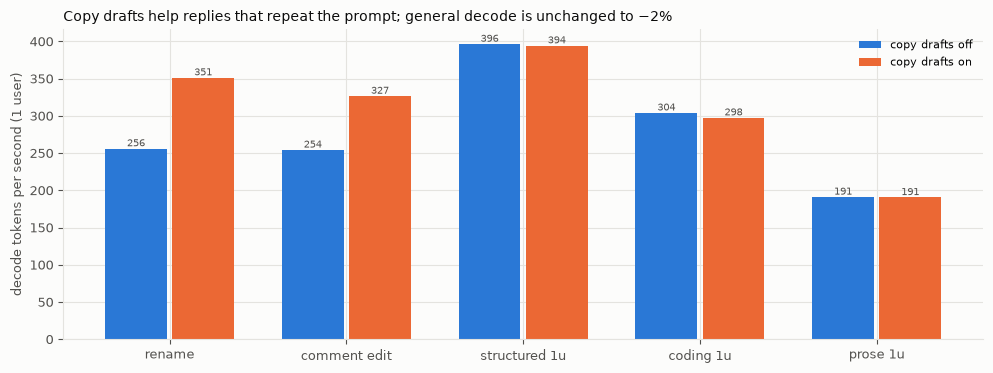

INFO 10-01 17:39:56 [copy_drafts.py:236] Copy drafts: 1169 of 16497 request-steps copied (7.1%)


In [9]:
CD = {v: matrix(RECEIPTS, f"copy-drafts-{v}") for v in ("off", "on")}
ED = {v: receipt(RECEIPTS, f"copy-drafts-{v}", "edit.json") for v in ("off", "on")}
table(["copy drafts", "1 user struct / code / prose", "8 users struct / code / prose", "edit: rename tok/s (sha)", "edit: comment tok/s (sha)"],
      [[v, " / ".join(f"{CD[v][(p, 1)]['tok']:.1f}" for p in PROMPTS), " / ".join(f"{CD[v][(p, 8)]['tok']:.1f}" for p in PROMPTS),
        f"{ED[v]['rename']['tok_s_median']:.1f} ({ED[v]['rename']['shas'][0]})", f"{ED[v]['docstring']['tok_s_median']:.1f} ({ED[v]['docstring']['shas'][0]})"] for v in ("off", "on")])
labels = ["rename", "comment edit"] + [f"{p} 1u" for p in PROMPTS]
off = [ED["off"]["rename"]["tok_s_median"], ED["off"]["docstring"]["tok_s_median"]] + [CD["off"][(p, 1)]["tok"] for p in PROMPTS]
on = [ED["on"]["rename"]["tok_s_median"], ED["on"]["docstring"]["tok_s_median"]] + [CD["on"][(p, 1)]["tok"] for p in PROMPTS]
fig, ax = plt.subplots(figsize=(10, 3.8))
w = 0.38
label_bars(ax, ax.bar([i - w / 2 for i in range(5)], off, w * 0.92, color=S[0], label="copy drafts off"))
label_bars(ax, ax.bar([i + w / 2 for i in range(5)], on, w * 0.92, color=S[1], label="copy drafts on"))
ax.set_xticks(range(5), labels); ax.set_ylabel("decode tokens per second (1 user)"); ax.legend(fontsize=8)
ax.set_title("Copy drafts help replies that repeat the prompt; general decode is unchanged to −2%", loc="left")
fig.tight_layout(); plt.show()
print(open(f"{RECEIPTS}/copy-drafts-on/server-key-lines.txt").read().splitlines()[-1])

### 2.6 SM VF offset (+200 MHz at a 1,410 MHz ceiling) — pending

The offset shifts the voltage/frequency curve so a clock is reached at a lower voltage. The risk is silent wrong results when hot, so each card is gated hot first (`170tune -i N gate 200 1410 12`). At the time of writing GPU 0 and GPU 1 had passed (12/12 sweeps + compute, peak HBM 75 °C / 76 °C), GPU 2 and GPU 3 were still running, and no serving bench with the offset exists. No number is claimed here; this section is updated when the receipts exist.

## 3. Reproduce

Hardware: 4 × CMP 170HX exposing 65,536 MiB each, forced-air cooling, ~200 GB disk for weights. Driver: cmpunlocker with `6c442ee` for 74 SMs; for the HBM step, PR #60's `hbm-control-plm.patch` plus [170tune](https://github.com/cachenetics/170tune).

```bash
# 1. Serve (as in the 2026-10-01 notebook; P2P off on PLX/older-Xeon hosts)
git clone https://github.com/Morrowmake/glm53-flash-cmp170hx-recipe && cd glm53-flash-cmp170hx-recipe && git checkout v1.6.0
printf 'LAYOUT=tp4\nMODELS_DIR=/path/to/models\nVLLM_ALLOW_PCIE_P2P_CUSTOM_ALLREDUCE=0\nVLLM_GLM5_REPLICATED_EMBED=1\n' > .env
./install.sh && ./download.sh && ./start.sh

# 2. Check each card's stock HBM clock (NDIV x 27 MHz); 54 = 1,458 MHz, 64 = 1,728 MHz
sudo 170tune -i 0 snapshot-stock    # repeat for each card

# 3. Gate and persist NDIV 64 on cards that ship at 54 (server stopped; one card at a time)
sudo GATE_TEMP=75 GATE_SOAK_MAX=600 170tune -i 1 hbm-gate --ndiv 64 --sweeps 12
sudo 170tune -i 1 persist save --ndiv 64 && sudo 170tune -i 1 persist enable

# 4. Bench: run_decode.sh at one cap, or sweep.sh across caps (live, no restart)
```

Set `GATE_TEMP` to the card's real serving HBM peak: a card that never reaches the target waits out the full soak before every sweep. 170tune's recover and crash-revert paths set the power limit to 250 W; re-apply your cap afterwards. Harness: [`run_decode.sh`](../results/2026-10-02-glm-5.3-flash-4card-tp4-plx-sm74-hbm-power/run_decode.sh), [`sweep.sh`](../results/2026-10-02-glm-5.3-flash-4card-tp4-plx-sm74-hbm-power/sweep.sh), [`bench_edit.py`](../results/2026-10-02-glm-5.3-flash-4card-tp4-plx-sm74-hbm-power/bench_edit.py).

## Try your own prompt

Edit `PROMPT`; with `LIVE = False` this prints the recorded structured run at 150 W (HBM equalised) instead.

In [10]:
PROMPT = "Count from 1 to 200. Output only the numbers, separated by spaces. No other text."
if LIVE:
    import urllib.request
    url = os.environ[ENDPOINT_ENV_VAR]
    body = {"model": "glm-5.3-flash", "messages": [{"role": "user", "content": PROMPT}], "max_tokens": 400, "temperature": 0,
            "chat_template_kwargs": {"enable_thinking": False}}
    req = urllib.request.Request(url + "/chat/completions", json.dumps(body).encode(), {"Content-Type": "application/json"})
    resp = json.load(urllib.request.urlopen(req, timeout=600))
    print(resp["choices"][0]["message"].get("content")); print(resp["usage"])
else:
    run = receipt(RECEIPTS, "sm74-hbm64-150w", "decode-structured-c1.json")["runs"][0]
    print(run["text_head"][:400]); print({k: run[k] for k in ("completion_tokens", "prompt_tokens", "tok_s", "ttft_s")})

The user wants me to count from 1 to 200, outputting only the numbers separated by spaces, with no other text. This is a straightforward request. Let me generate the numbers 1 through 200 separated by spaces.1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 
{'completion_tokens': 400, 'prompt_tokens': 33, 'tok_s': 418.5441198323365, 'ttft_s': 0.09525167599986162}


<details><summary>Appendix</summary>

- **nvidia-smi does not show the new HBM clock.** After `170tune` raises NDIV live, `nvidia-smi --query-gpu=clocks.mem` keeps reporting the value cached at driver load (1,458 MHz on the re-clocked cards). `170tune -i N status` reads the PLL. Telemetry in these receipts therefore shows 1,458 MHz for two cards in every run.
- **Gate temperature.** 170tune's default `GATE_TEMP` is 60 °C. This host serves at HBM 72–75 °C, so the HBM gates ran at 75 °C. The coolest card never reached 75 °C (or 72 °C) during the SM-offset gate and each sweep waited out the 600 s soak; it was re-run at 70 °C, its measured serving range.
- **Power-limit side effects.** 170tune soaks at 300 W and its `recover` / crash-revert paths set 250 W. A systemd drop-in re-applies the host cap after 170tune's services.
- **Not measured:** prefill and long-context at 74 SM / equal HBM, quality suites, and the SM offset serving bench.
- **Licences.** Recipe MIT; drafter CC BY-NC-ND 4.0 (benchmark only); MiaAI-Lab bench AGPL-3.0, referenced by commit, not vendored; `bench_edit.py` uses Python's own `textwrap.py` (PSF licence) as the edit input.

</details>